In [1]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "raw"

print(RAW_PATH)

d:\Railway_AI_Inspector\data\raw


In [2]:
image_info = []

classes = [
    "normal",
    "crack",
    "broken_rail",
    "misalignment",
    "surface_wear"
]

for cls in classes:

    folder = RAW_PATH / cls

    for img_path in folder.glob("*"):

        try:

            img = Image.open(img_path)

            width, height = img.size

            image_info.append({
                "class": cls,
                "file": img_path.name,
                "width": width,
                "height": height,
                "format": img.format
            })

        except Exception as e:
            print(f"Error reading {img_path.name}: {e}")

df = pd.DataFrame(image_info)

df.head()

,class,file,width,height,format
0,normal,Images_09.jpeg,326,154,JPEG
1,normal,Normal_01.jpeg,259,194,JPEG
2,normal,Normal_02.jpg,740,493,JPEG
3,normal,Normal_03.jpeg,186,271,JPEG
4,normal,Normal_04.webp,390,280,WEBP


In [3]:
print("Total Images:", len(df))

print("\nImage Formats:")
print(df["format"].value_counts())

print("\nWidth Statistics:")
print(df["width"].describe())

print("\nHeight Statistics:")
print(df["height"].describe())

Total Images: 100

Image Formats:
format
JPEG    82
WEBP    15
PNG      2
AVIF     1
Name: count, dtype: int64

Width Statistics:
count     100.000000
mean      659.200000
std       604.564323
min       168.000000
25%       261.500000
50%       431.000000
75%       903.000000
max      4000.000000
Name: width, dtype: float64

Height Statistics:
count     100.000000
mean      521.180000
std       670.529195
min       148.000000
25%       193.500000
50%       280.000000
75%       671.250000
max      6000.000000
Name: height, dtype: float64


In [4]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

classes = [
    "normal",
    "crack",
    "broken_rail",
    "misalignment",
    "surface_wear"
]

for cls in classes:
    (PROCESSED_PATH / cls).mkdir(parents=True, exist_ok=True)

print("Processed folders created successfully.")

Processed folders created successfully.


In [5]:
from PIL import Image

TARGET_SIZE = (224, 224)

processed_count = 0

for cls in classes:

    input_folder = RAW_PATH / cls
    output_folder = PROCESSED_PATH / cls

    for img_path in input_folder.glob("*"):

        try:

            img = Image.open(img_path)

            img = img.convert("RGB")

            img = img.resize(TARGET_SIZE)

            output_file = output_folder / f"{img_path.stem}.jpg"

            img.save(output_file, "JPEG")

            processed_count += 1

        except Exception as e:

            print(f"Error processing {img_path.name}: {e}")

print(f"\nTotal Processed Images: {processed_count}")


Total Processed Images: 100


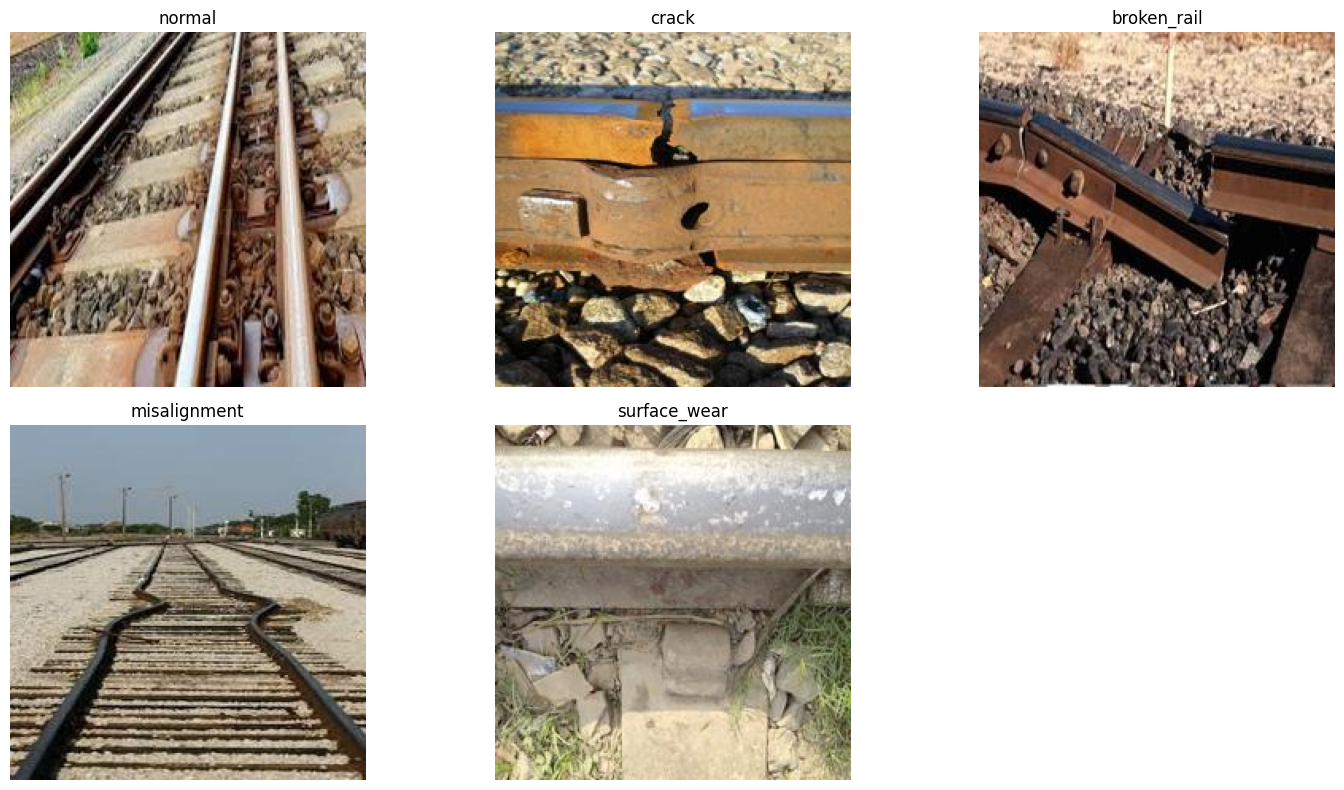

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

classes = [
    "normal",
    "crack",
    "broken_rail",
    "misalignment",
    "surface_wear"
]

plt.figure(figsize=(15, 8))

for i, cls in enumerate(classes):

    folder = PROCESSED_PATH / cls

    sample_image = list(folder.glob("*.jpg"))[0]

    img = Image.open(sample_image)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
sizes = []

for cls in classes:

    folder = PROCESSED_PATH / cls

    for img_path in folder.glob("*.jpg"):

        img = Image.open(img_path)

        sizes.append(img.size)

unique_sizes = set(sizes)

print("Unique Image Sizes:")
print(unique_sizes)

print("\nTotal Processed Images:")
print(len(sizes))

Unique Image Sizes:
{(224, 224)}

Total Processed Images:
100
